# Lab 2: Exponential Smoothing & ETS Models (Student Version)

## Objective
Apply State-Space models to the Daily Climate Delhi Dataset:
1. Exploratory Data Analysis for Seasonality.
2. Seasonal Decomposition (Additive vs. Multiplicative).
3. Exponential Smoothing (Simple, Holt, and Holt-Winters).
4. Building and Automated Model Selection for ETS.
5. Forecasting and Prediction Intervals.

### Task 1: Import Necessary Libraries
Import the standard data science and statsmodels libraries for Exponential Smoothing.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - SimpleExpSmoothing, Holt, ExponentialSmoothing (from statsmodels.tsa.holtwinters)
# - ETSModel (from statsmodels.tsa.exponential_smoothing.ets)

# SOLUTION 1:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import math


### Task 2: Load the Dataset
We are using the sumanthvrao/daily-climate-time-series-data dataset. 
- We are interested in the meantemp column.

In [31]:
# TODO 2: Load the 'DailyDelhiClimateTrain.csv' dataset using pandas.
df = pd.read_csv('DailyDelhiClimateTrain.csv')

# Display first few rows and check for data types.
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


### Task 3: Indexing and Frequency
ETS models in statsmodels require a clear frequency (e.g., 'D' for Daily) and a DatetimeIndex.

In [ ]:
# TODO 3.1: Convert 'date' to datetime and set it as the index.
# SOLUTION 3.1:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# TODO 3.2: Set the frequency to 'D' (Daily). Use .asfreq('D') if necessary.
temp_series = df['meantemp']
temp_series = temp_series.asfreq('D')
print(f"Date range: {temp_series.index.min()} to {temp_series.index.max()}")
print(f"Series length: {len(temp_series)} days")
print(f"Missing values: {temp_series.isnull().sum()}")

Date range: 2013-01-01 00:00:00 to 2017-01-01 00:00:00
Series length: 1462 days
Missing values: 0


### Task 4: Seasonal Decomposition
Visualize the Error, Trend, and Seasonality components.

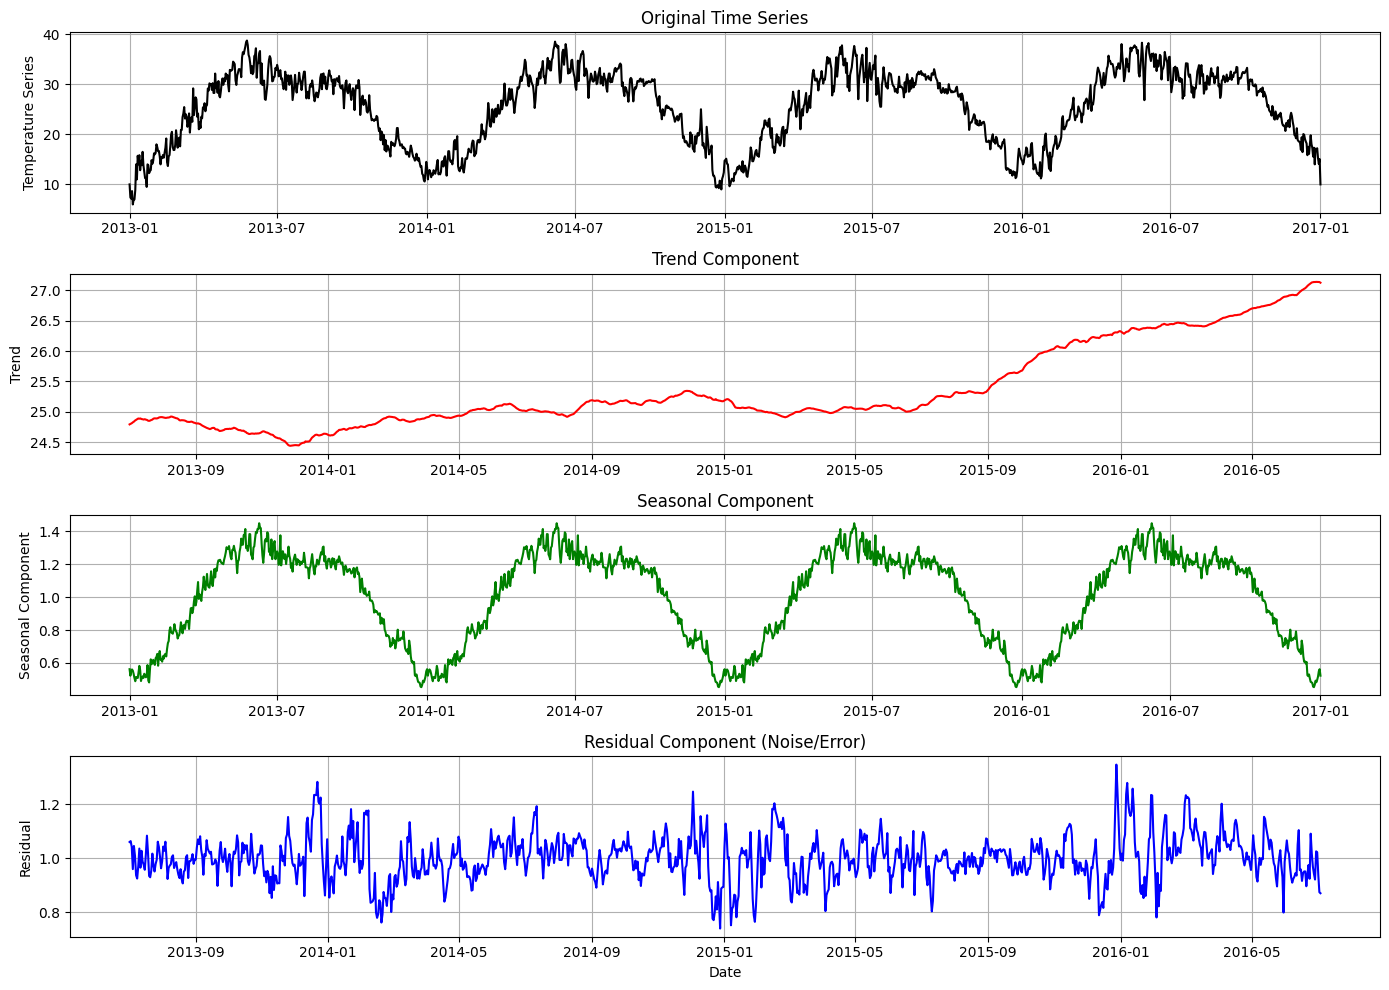

In [ ]:
# TODO 4: Perform seasonal decomposition with period=365.
# Choose between 'additive' or 'multiplicative'. 
# Hint: Does the seasonal variation change as the temperature increases?

result = seasonal_decompose(temp_series, model='multiplicative', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(temp_series, color="black")
axes[0].set_ylabel('Temperature Series')
axes[0].set_title('Original Time Series')
axes[0].grid()

axes[1].plot(result.trend, label='Trend', color='red')
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component')
axes[1].grid()

axes[2].plot(result.seasonal, label='Seasonal', color='green')
axes[2].set_ylabel('Seasonal Component')
axes[2].set_title('Seasonal Component')
axes[2].grid()

axes[3].plot(result.resid, label='Residual', color='blue')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].set_title('Residual Component (Noise/Error)')
axes[3].grid()

plt.tight_layout()
plt.show()

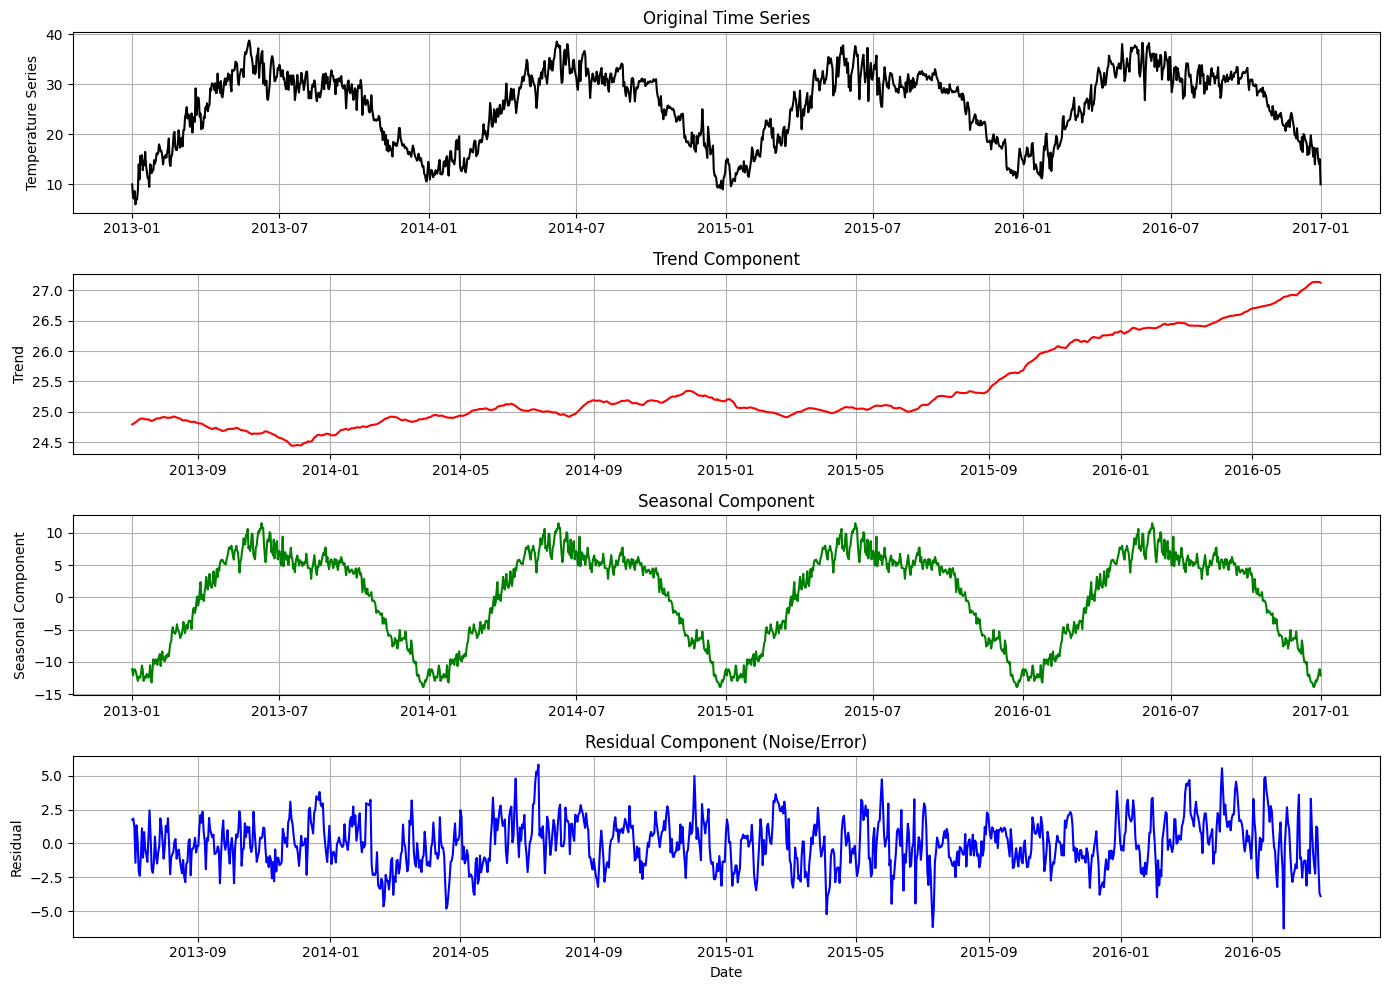

In [ ]:
# TODO 4: Perform seasonal decomposition with period=365.
# Choose between 'additive' or 'multiplicative'. 
# Hint: Does the seasonal variation change as the temperature increases?

result = seasonal_decompose(temp_series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(temp_series, color="black")
axes[0].set_ylabel('Temperature Series')
axes[0].set_title('Original Time Series')
axes[0].grid()

axes[1].plot(result.trend, label='Trend', color='red')
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component')
axes[1].grid()

axes[2].plot(result.seasonal, label='Seasonal', color='green')
axes[2].set_ylabel('Seasonal Component')
axes[2].set_title('Seasonal Component')
axes[2].grid()

axes[3].plot(result.resid, label='Residual', color='blue')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].set_title('Residual Component (Noise/Error)')
axes[3].grid()

plt.tight_layout()
plt.show()

### Task 5: Simple Exponential Smoothing (SES)
Start with the simplest form: no trend and no seasonality.

  AIC: 1454.05
  BIC: 1464.62


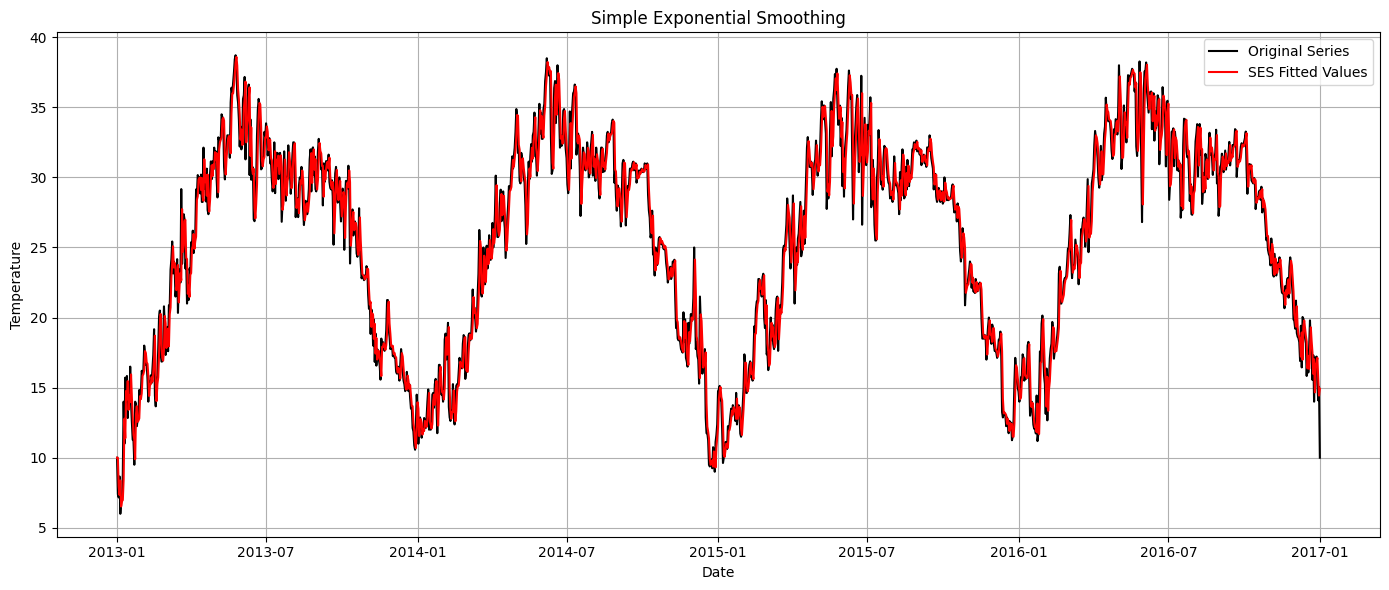


SES Training RMSE: 1.6420


In [ ]:
# TODO 5: Fit a SimpleExpSmoothing model.
# Experiment with different 'smoothing_level' (alpha) values or let it optimize automatically.

ses_model = SimpleExpSmoothing(temp_series).fit(optimized=True)
ses_fitted = ses_model.fittedvalues
print(f"  AIC: {ses_model.aic:.2f}")
print(f"  BIC: {ses_model.bic:.2f}")


fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temp_series, label='Original Series', color='black')
ax.plot(ses_fitted, label='SES Fitted Values', color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.set_title('Simple Exponential Smoothing')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

ses_rmse = np.sqrt(np.mean((temp_series - ses_fitted)**2))
print(f"\nSES Training RMSE: {ses_rmse:.4f}")

### Task 6: Holt’s Linear Trend Model
Add the Trend component to handle potential long-term increases.

In [ ]:
# TODO 6: Fit a Holt model (ExponentialSmoothing with trend='add').
# Question: Is a damped trend necessary for climate data? Try both.

holt_linear = Holt(temp_series).fit(optimized=True)
holt_damped = Holt(temp_series, damped_trend=True).fit(optimized=True)

print("Linear Trend: ")
print(f"  AIC: {holt_linear.aic:.4f}")
print(f"  BIC:  {holt_linear.bic:.4f}")

rmse_linear = np.sqrt(np.mean((temp_series - holt_linear.fittedvalues)**2))
print(f"  RMSE: {rmse_linear:.4f}")

print("Damped Trend: ")
print(f"  AIC: {holt_damped.aic:.4f}")
print(f"  BIC:  {holt_damped.bic:.4f}")
rmse_damped = np.sqrt(np.mean((temp_series - holt_damped.fittedvalues)**2))
print(f"  RMSE: {rmse_damped:.4f}")

Linear Trend: 
  AIC: 1551.1236
  BIC:  1572.2739
  RMSE: 1.6951
Damped Trend: 
  AIC: 1464.4168
  BIC:  1490.8547
  RMSE: 1.6445


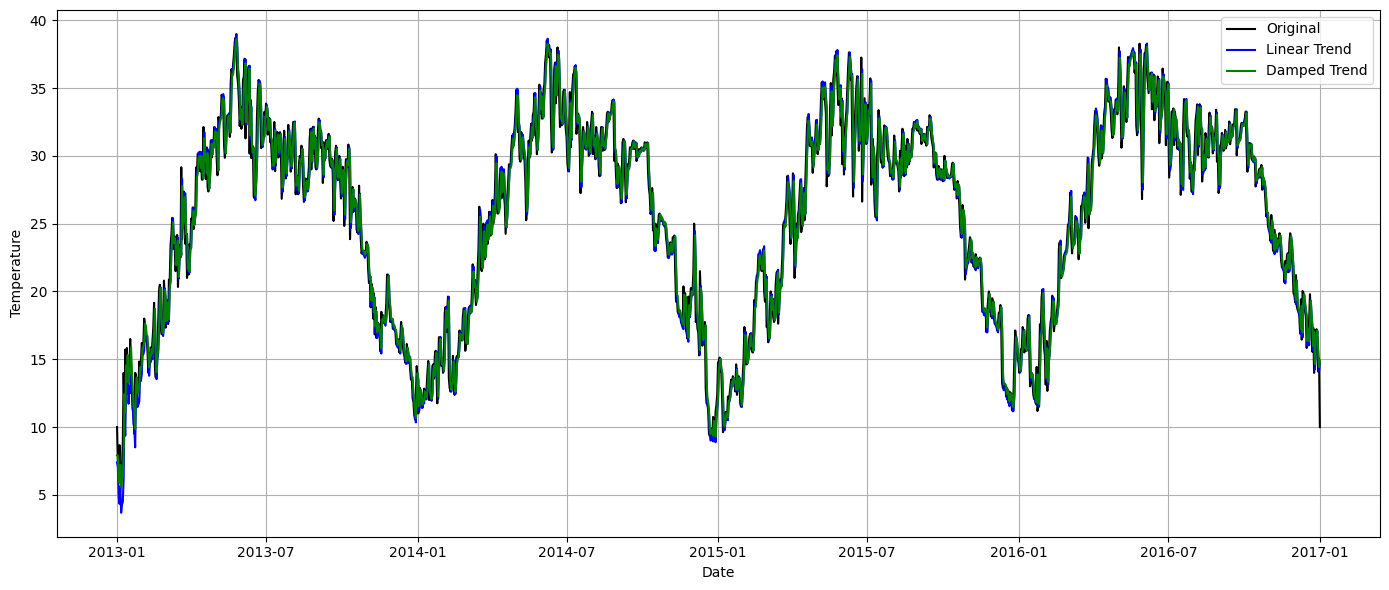

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temp_series, label='Original', color='black')
ax.plot(holt_linear.fittedvalues, label='Linear Trend', color='blue')
ax.plot(holt_damped.fittedvalues, label='Damped Trend', color='green')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

### Task 7: Holt-Winters (Triple Exponential Smoothing)
Add the Seasonality component to capture the yearly cycles.

In [ ]:
# TODO 7: Fit an ExponentialSmoothing model with trend='add', seasonal='add', and seasonal_periods=365.
hw_add = ExponentialSmoothing(temp_series, trend='add', seasonal='add', 
                              seasonal_periods=365).fit(optimized=True)
hw_mul = ExponentialSmoothing(temp_series, trend='add', seasonal='mul', 
                              seasonal_periods=365).fit(optimized=True)
print("Additive Seasonality:")
print(f"  AIC: {hw_add.aic:.4f}")
print(f"  BIC:  {hw_add.bic:.4f}")
rmse_hw_add = np.sqrt(np.mean((temp_series - hw_add.fittedvalues)**2))
print(f"  RMSE: {rmse_hw_add:.4f}")

print("\nMultiplicative Seasonality:")
print(f"  AIC: {hw_mul.aic:.4f}")
print(f"  BIC:  {hw_mul.bic:.4f}")
rmse_hw_mul = np.sqrt(np.mean((temp_series - hw_mul.fittedvalues)**2))
print(f"  RMSE: {rmse_hw_mul:.4f}")

d:\anaconda\envs\iti\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Additive Seasonality:
  AIC: 1754.4975
  BIC:  3705.6074
  RMSE: 1.4157

Multiplicative Seasonality:
  AIC: 1748.6161
  BIC:  3699.7260
  RMSE: 1.4129


d:\anaconda\envs\iti\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


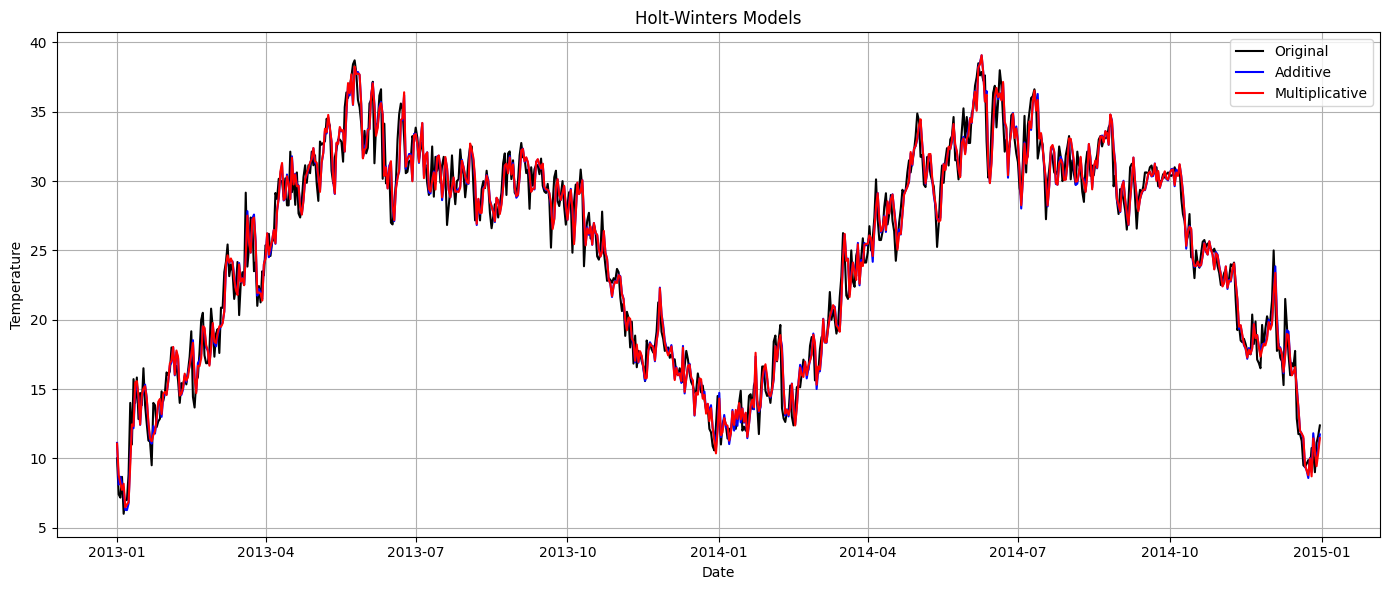

In [40]:
# 730 days plot -> 2years
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temp_series.iloc[:730], label='Original', color='black')
ax.plot(hw_add.fittedvalues.iloc[:730], label='Additive', color='blue')
ax.plot(hw_mul.fittedvalues.iloc[:730], label='Multiplicative', color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.set_title('Holt-Winters Models')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

### Task 8: The ETS State-Space Model
Use the formal ETSModel which allows for automated likelihood-based selection.

In [41]:
# TODO 8: Fit an ETSModel with error='add', trend='add', seasonal='add', and seasonal_periods=365.
ets_fit = ETSModel(temp_series, error='add', trend='add', seasonal='add', seasonal_periods=365).fit()

print("Model Configuration: AAdA (Additive Error, Trend, Seasonality)")
print(f"AIC: {ets_fit.aic:.2f}")
print(f"BIC: {ets_fit.bic:.2f}")

ets_fitted = ets_fit.fittedvalues
ets_rmse = np.sqrt(np.mean((temp_series - ets_fitted)**2))
print(f"\nFit Quality:")
print(f"ETS RMSE:{ets_rmse:.4f}°C")
print(f"MUL RMSE:{rmse_hw_mul:.4f}°C")
print(f"Difference:{abs(ets_rmse - rmse_hw_mul):.4f}°C")

d:\anaconda\envs\iti\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model Configuration: AAdA (Additive Error, Trend, Seasonality)
AIC: 6052.31
BIC: 8014.00

Fit Quality:
ETS RMSE:1.4876°C
MUL RMSE:1.4129°C
Difference:0.0747°C


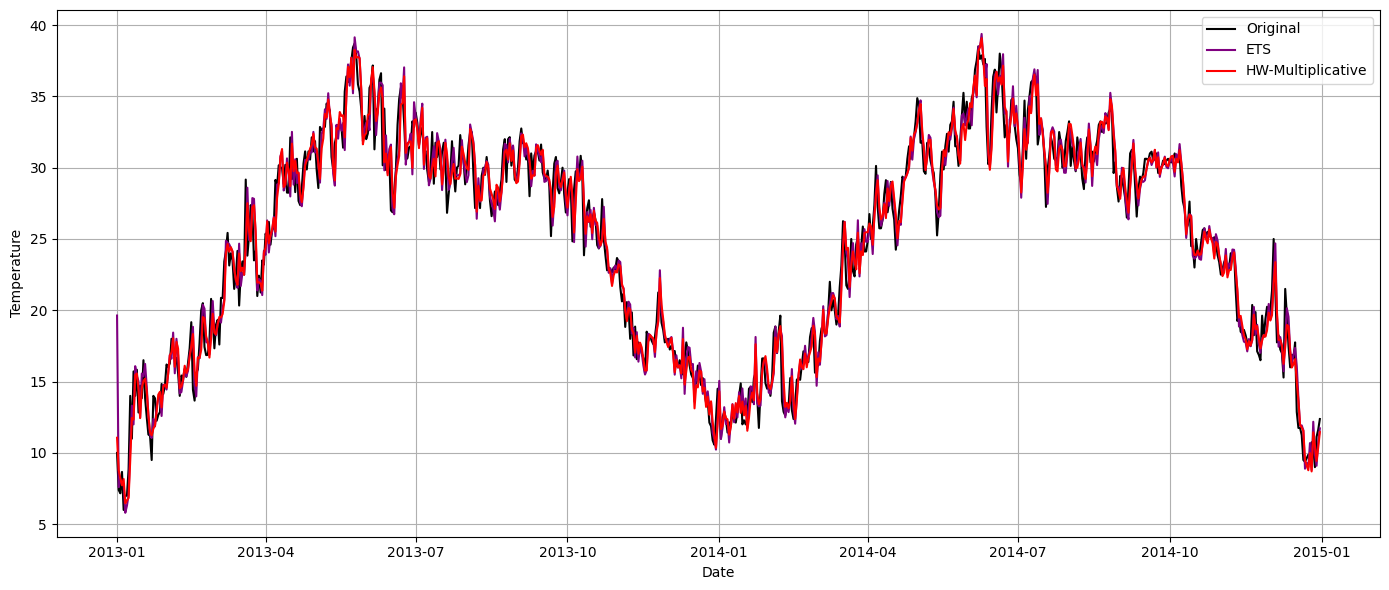

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temp_series.iloc[:730], label='Original', color='black')
ax.plot(ets_fitted.iloc[:730], label='ETS', color='purple')
ax.plot(hw_mul.fittedvalues.iloc[:730], label='HW-Multiplicative', color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

### Task 9: Evaluation & Forecasting
Forecast the temperature for the next 30 days and compare with the provided Test set.

In [43]:
# TODO 9.1: Load 'DailyDelhiClimateTest.csv'.
df_test = pd.read_csv('DailyDelhiClimateTest.csv')
df_test['date'] = pd.to_datetime(df_test['date'])
df_test.set_index('date', inplace=True)
temp_test = df_test['meantemp']
print(f"Date range:{temp_test.index.min()} to {temp_test.index.max()}")

# TODO 9.2: Generate forecasts using your best model (HW or ETSModel).
forecast_steps = len(temp_test)
hw_forecast = hw_mul.forecast(steps=forecast_steps)
hw_test_rmse = np.sqrt(np.mean((temp_test - hw_forecast)**2))
print(f"  HW Test RMSE: {hw_test_rmse:.4f}°C")

Date range:2017-01-01 00:00:00 to 2017-04-24 00:00:00
  HW Test RMSE: 3.1073°C


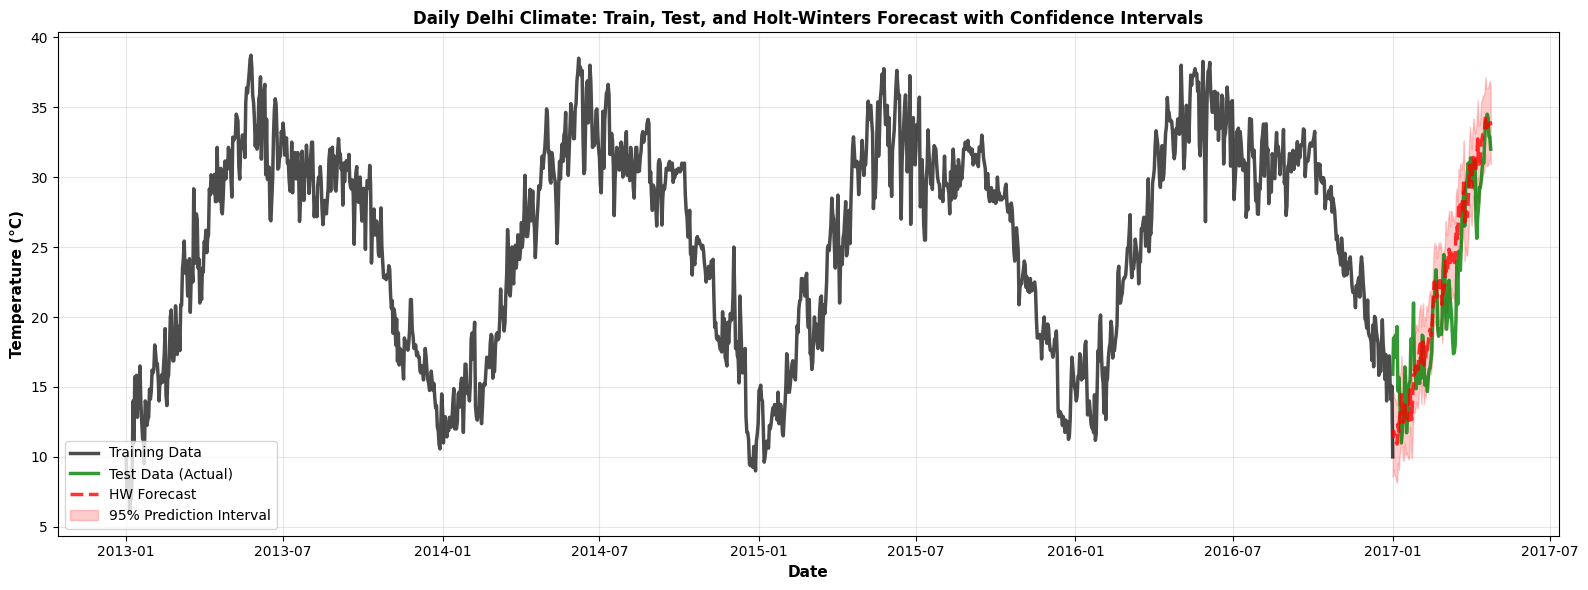

Forecast Statistics:
Mean forecast: 22.37°C
Mean actual test: 21.71°C
Forecast bias: 0.66°C
95% CI width: ±2.77°C


In [45]:
# TODO 9.3: Plot Train, Test, and Forecast.

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(temp_series, label='Training Data', color='black', linewidth=2.5, alpha=0.7)
ax.plot(temp_test, label='Test Data (Actual)', color='green', linewidth=2.5, alpha=0.8)
ax.plot(temp_test.index, hw_forecast, label='HW Forecast', color='red', linewidth=2.5, alpha=0.8, linestyle='--')
residuals = temp_series - hw_mul.fittedvalues
std_resid = np.std(residuals)
confidence_95 = 1.96
upper_bound = hw_forecast + confidence_95 * std_resid
lower_bound = hw_forecast - confidence_95 * std_resid

ax.fill_between(temp_test.index, lower_bound, upper_bound, alpha=0.2, color='red', label='95% Prediction Interval')

ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax.set_title('Daily Delhi Climate: Train, Test, and Holt-Winters Forecast with Confidence Intervals', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Forecast Statistics:")
print(f"Mean forecast: {hw_forecast.mean():.2f}°C")
print(f"Mean actual test: {temp_test.mean():.2f}°C")
print(f"Forecast bias: {hw_forecast.mean() - temp_test.mean():.2f}°C")
print(f"95% CI width: ±{confidence_95 * std_resid:.2f}°C")

### Task 10: Model Comparison
Compare the RMSE of the Holt-Winters model vs. a simple mean baseline.

In [ ]:
# TODO 10: Calculate and print the RMSE for your forecast.
models_comparison = {
    'SES': (ses_model.forecast(forecast_steps), ses_rmse),
    'Holt-Linear': (holt_linear.forecast(forecast_steps), rmse_linear),
    'Holt-Damped': (holt_damped.forecast(forecast_steps), rmse_damped),
    'HW-Additive': (hw_add.forecast(forecast_steps), rmse_hw_add),
    'HW-Multiplicative': (hw_mul.forecast(forecast_steps), rmse_hw_mul),
    'ETS (AAdA)': (ets_fit.forecast(forecast_steps), ets_rmse),
}

mean_baseline = np.repeat(temp_series.mean(), forecast_steps)
baseline_rmse = np.sqrt(np.mean((temp_test - mean_baseline)**2))

print("FINAL MODEL COMPARISON - TEST SET PERFORMANCE")
print(f"Test set size: {len(temp_test)} observations")
print(f"Date range: {temp_test.index.min().date()} to {temp_test.index.max().date()}\n")

results_table = []
for model_name, (forecast, train_rmse) in models_comparison.items():
    test_rmse = np.sqrt(np.mean((temp_test - forecast)**2))
    results_table.append((model_name, train_rmse, test_rmse))
    print(f"{model_name:18s} | Train RMSE: {train_rmse:6.2f}°C | Test RMSE: {test_rmse:6.2f}°C")

FINAL MODEL COMPARISON - TEST SET PERFORMANCE
Test set size: 114 observations
Date range: 2017-01-01 to 2017-04-24

SES                | Train RMSE:   1.64°C | Test RMSE:  12.42°C
Holt-Linear        | Train RMSE:   1.70°C | Test RMSE:  35.21°C
Holt-Damped        | Train RMSE:   1.64°C | Test RMSE:  12.45°C
HW-Additive        | Train RMSE:   1.42°C | Test RMSE:   3.48°C
HW-Multiplicative  | Train RMSE:   1.41°C | Test RMSE:   3.11°C
ETS (AAdA)         | Train RMSE:   1.49°C | Test RMSE:   3.33°C
